# Titanic Dataset – Exploratory Data Analysis

**Name:** Abdlrhman Hisham Ismail
**ID:** AI2617

In this notebook, we explore the Titanic dataset using Pandas. We walk through loading the data, cleaning it, performing exploratory analysis, drawing insights, and summarizing our findings.

## Step 1 – Load the Data

We start by importing the necessary libraries and loading the Titanic CSV file into a Pandas DataFrame. Then we inspect the data using `head()`, `info()`, and `describe()` to understand its structure, types, and basic statistics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Loading the CSV file

We read the Titanic dataset from the local `DataSet` folder into a DataFrame called `df`.

In [2]:
df = pd.read_csv('./DataSet/titanic.csv')

### First look at the data

We display the first five rows to get a feel for the columns and the kind of values they contain.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Column types and non-null counts

`info()` reveals the data types and how many non-null entries each column has, helping us spot columns with missing data early.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Summary statistics

`describe(include="all")` gives us a comprehensive statistical overview: count, mean, std, min/max for numeric columns, and unique/top/freq for categorical ones.

In [5]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Step 2 – Data Cleaning

Before drawing any conclusions, we need to handle missing values and remove unreliable columns. We start by checking which columns have nulls and how many.

In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Imputing missing `Age` values

Rather than dropping rows with missing `Age`, we fill them with the **median age**. This preserves all passengers and provides a simple, robust estimate when the true age is unknown.

In [7]:
df = df.fillna({'Age': df['Age'].median()})

### Dropping the `Cabin` column

The `Cabin` column contains a **very high proportion of missing values**, so it is more practical to drop it entirely instead of trying to impute it. Keeping it would add noise and complexity without much reliable information.

In [8]:
df = df.drop(columns=['Cabin'])

### Handling missing values in `Embarked`

The `Embarked` column has only a couple of missing values and is categorical, so we fill the nulls with the **most frequent port** (the mode). This keeps all passengers in the dataset without making strong numerical assumptions.

In [9]:
df = df.fillna({'Embarked': df['Embarked'].mode()[0]})

### Verifying the cleaned data

After all imputations and drops, we confirm that no missing values remain in the dataset.

In [10]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Checking for duplicate rows

We also verify that the dataset contains no duplicate rows, which could skew our analysis.

In [11]:
df.duplicated().sum()

np.int64(0)

## Step 3 – Exploratory Data Analysis (EDA)

Now that the data is clean, we explore distributions and patterns. We start by looking at how passenger ages are distributed.

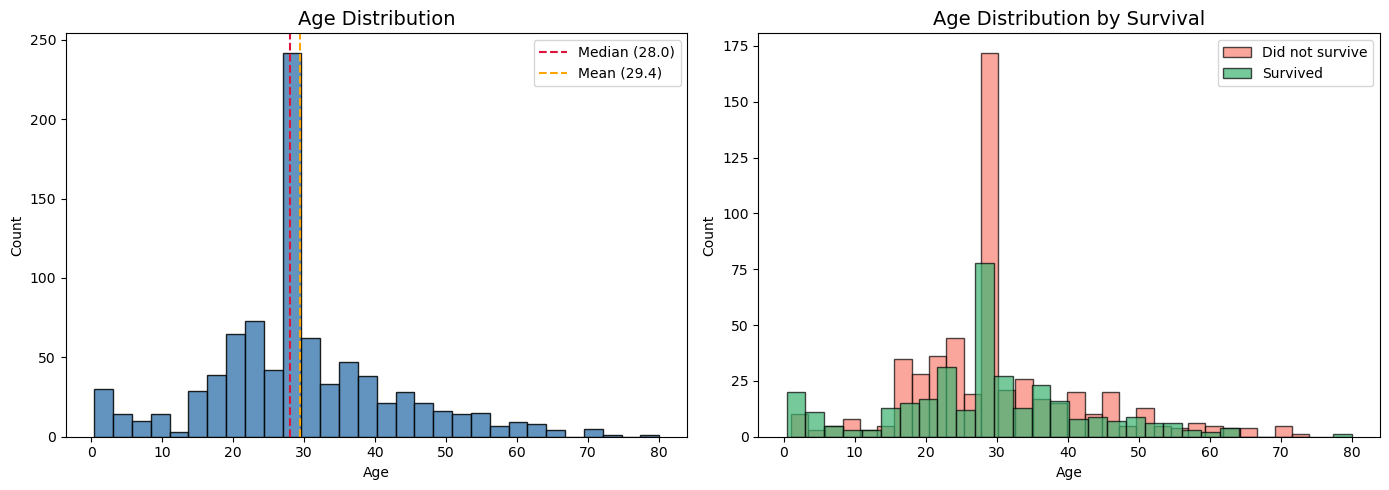

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Age'], bins=30, edgecolor='black', color='steelblue', alpha=0.85)
axes[0].axvline(df['Age'].median(), color='crimson', linestyle='--', linewidth=1.5, label=f"Median ({df['Age'].median():.1f})")
axes[0].axvline(df['Age'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean ({df['Age'].mean():.1f})")
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

survived = df[df['Survived'] == 1]['Age']
not_survived = df[df['Survived'] == 0]['Age']
axes[1].hist(not_survived, bins=30, edgecolor='black', color='salmon', alpha=0.7, label='Did not survive')
axes[1].hist(survived, bins=30, edgecolor='black', color='mediumseagreen', alpha=0.7, label='Survived')
axes[1].set_title('Age Distribution by Survival', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

### Fare Distribution

Let's look at how ticket fares are distributed. Since fares are often skewed (a few passengers paid much more than the rest), we plot a histogram alongside a boxplot to catch outliers.

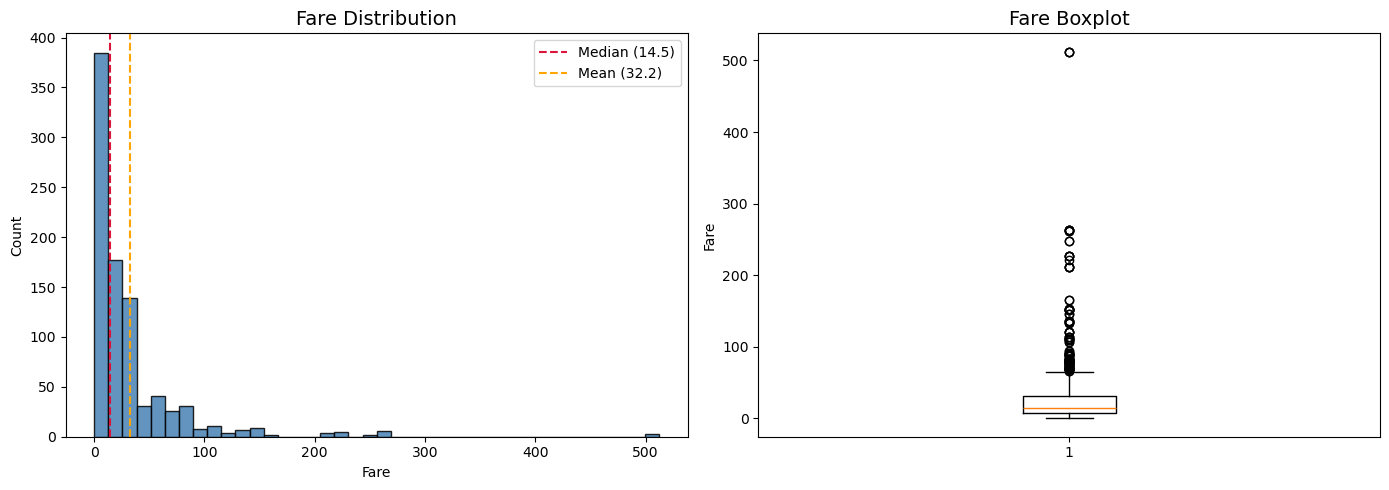

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Fare'], bins=40, edgecolor='black', color='steelblue', alpha=0.85)
axes[0].axvline(df['Fare'].median(), color='crimson', linestyle='--', linewidth=1.5, label=f"Median ({df['Fare'].median():.1f})")
axes[0].axvline(df['Fare'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean ({df['Fare'].mean():.1f})")
axes[0].set_title('Fare Distribution', fontsize=14)
axes[0].set_xlabel('Fare')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['Fare'], vert=True)
axes[1].set_title('Fare Boxplot', fontsize=14)
axes[1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

### Passenger Class and Gender Distributions

We look at the counts of passengers in each class and by gender. These are two of the strongest predictors of survival.

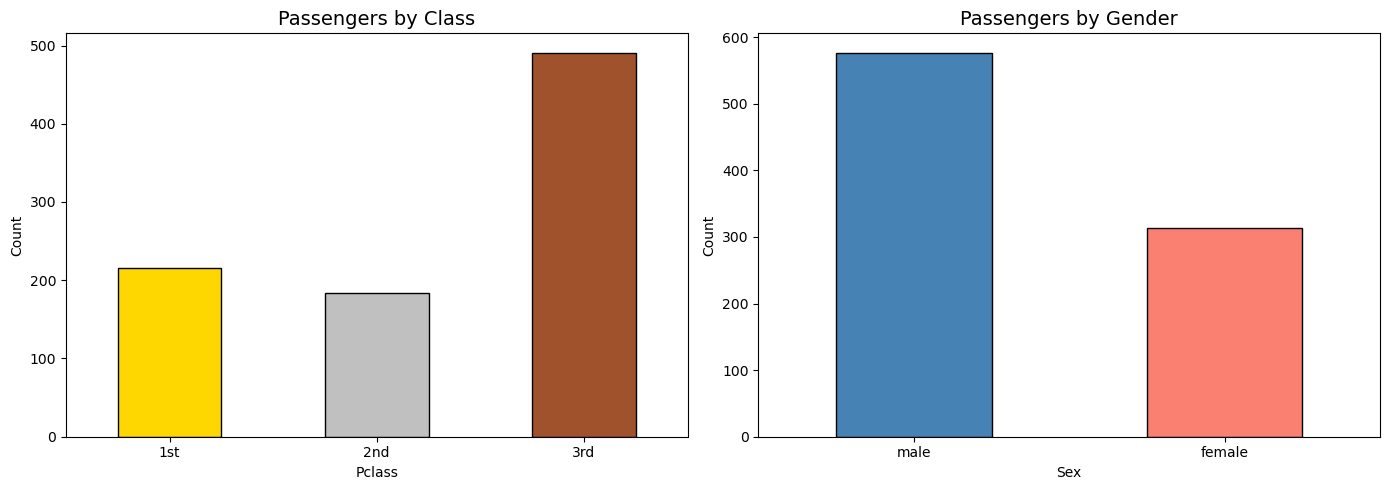

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pclass_counts = df['Pclass'].value_counts().sort_index()
pclass_counts.plot(kind='bar', ax=axes[0], color=['gold', 'silver', 'sienna'], edgecolor='black')
axes[0].set_title('Passengers by Class', fontsize=14)
axes[0].set_xlabel('Pclass')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

sex_counts = df['Sex'].value_counts()
sex_counts.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('Passengers by Gender', fontsize=14)
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(sex_counts.index, rotation=0)

plt.tight_layout()
plt.show()

### 3.2 Survival Rates Overview

Before diving into group comparisons, let's see the **overall survival rate** and the split between survived and not survived.

In [15]:
print(f"Overall survival rate: {df['Survived'].mean():.2%}")
print()

survival_pct = df['Survived'].value_counts(normalize=True)
print("Survival breakdown:")
print(f"  Did not survive: {survival_pct[0]:.2%}")
print(f"  Survived:        {survival_pct[1]:.2%}")

Overall survival rate: 38.38%

Survival breakdown:
  Did not survive: 61.62%
  Survived:        38.38%


### 3.3 Grouped Summaries

Now we explore how survival rate varies across key categories: **Gender**, **Passenger Class**, and **Embarkation Port**. We compute the group means and visualize them side by side.

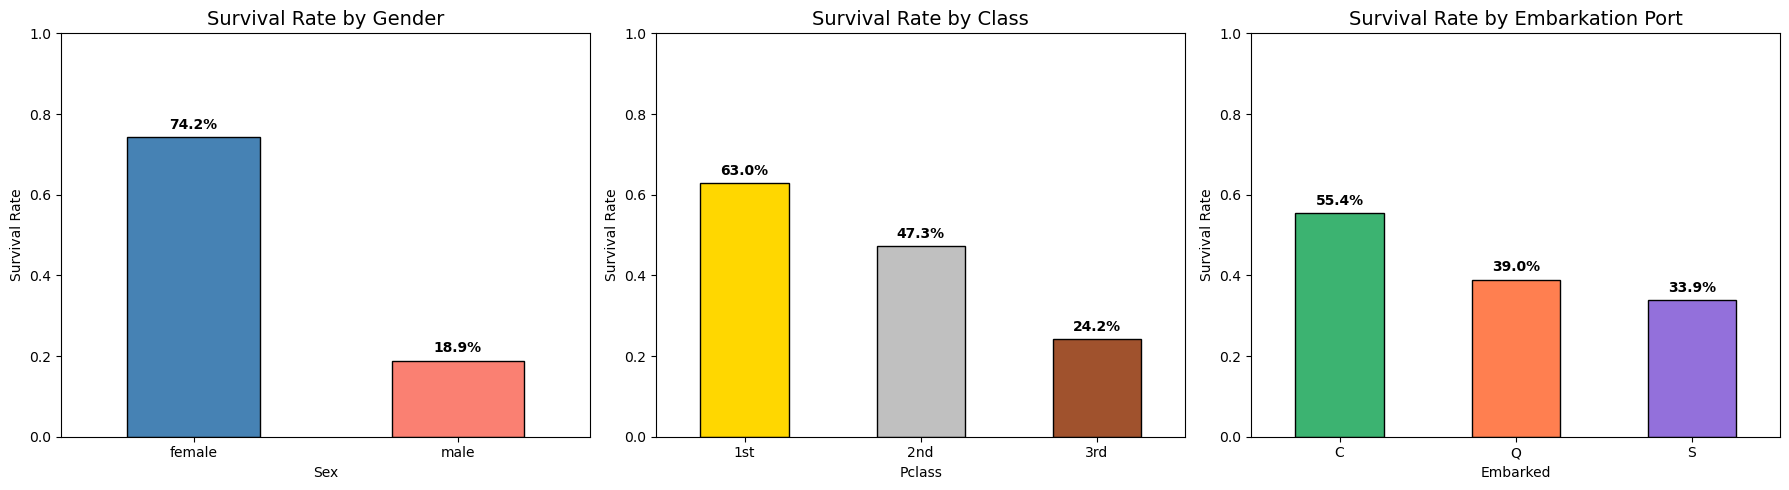

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Survival rate by Gender
surv_by_sex = df.groupby('Sex')['Survived'].mean()
surv_by_sex.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Survival Rate by Gender', fontsize=14)
axes[0].set_ylabel('Survival Rate')
axes[0].set_xticklabels(surv_by_sex.index, rotation=0)
axes[0].set_ylim(0, 1)
for i, v in enumerate(surv_by_sex):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Survival rate by Passenger Class
surv_by_class = df.groupby('Pclass')['Survived'].mean()
surv_by_class.plot(kind='bar', ax=axes[1], color=['gold', 'silver', 'sienna'], edgecolor='black')
axes[1].set_title('Survival Rate by Class', fontsize=14)
axes[1].set_ylabel('Survival Rate')
axes[1].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
axes[1].set_ylim(0, 1)
for i, v in enumerate(surv_by_class):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

# Survival rate by Embarkation Port
surv_by_embarked = df.groupby('Embarked')['Survived'].mean()
surv_by_embarked.plot(kind='bar', ax=axes[2], color=['mediumseagreen', 'coral', 'mediumpurple'], edgecolor='black')
axes[2].set_title('Survival Rate by Embarkation Port', fontsize=14)
axes[2].set_ylabel('Survival Rate')
axes[2].set_xticklabels(surv_by_embarked.index, rotation=0)
axes[2].set_ylim(0, 1)
for i, v in enumerate(surv_by_embarked):
    axes[2].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Grouped summary tables

Let's also print the exact numbers behind the charts above.

In [17]:
print("Survival rate by Gender:")
print(df.groupby('Sex')['Survived'].mean().to_string())
print()
print("Survival rate by Passenger Class:")
print(df.groupby('Pclass')['Survived'].mean().to_string())
print()
print("Survival rate by Embarkation Port:")
print(df.groupby('Embarked')['Survived'].mean().to_string())

Survival rate by Gender:
Sex
female    0.742038
male      0.188908

Survival rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363

Survival rate by Embarkation Port:
Embarked
C    0.553571
Q    0.389610
S    0.339009


## Step 4 – Analysis & Insights

In this section we ask specific questions about the data and answer them using Pandas operations and visualizations.

### Q1: Did women have a higher survival rate than men?

        Survival Rate  Survived Count  Total  Did Not Survive
Sex                                                          
female       0.742038             233    314               81
male         0.188908             109    577              468


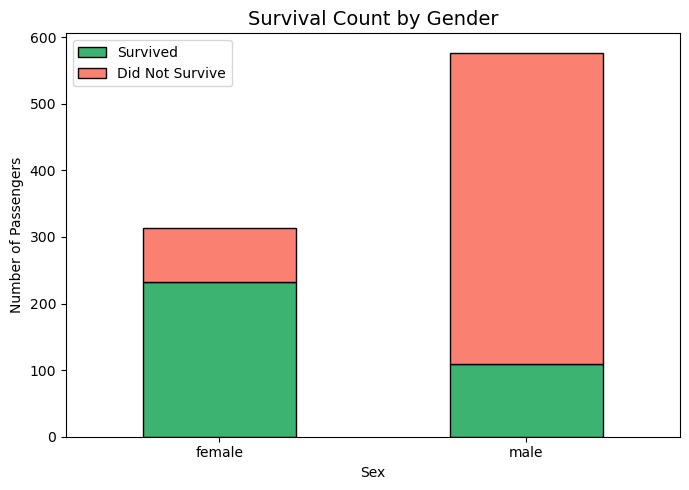

In [18]:
surv_by_sex = df.groupby('Sex')['Survived'].agg(['mean', 'sum', 'count'])
surv_by_sex.columns = ['Survival Rate', 'Survived Count', 'Total']
surv_by_sex['Did Not Survive'] = surv_by_sex['Total'] - surv_by_sex['Survived Count']
print(surv_by_sex)

fig, ax = plt.subplots(figsize=(7, 5))
surv_by_sex[['Survived Count', 'Did Not Survive']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['mediumseagreen', 'salmon'], edgecolor='black'
)
ax.set_title('Survival Count by Gender', fontsize=14)
ax.set_ylabel('Number of Passengers')
ax.set_xticklabels(['female', 'male'], rotation=0)
ax.legend(['Survived', 'Did Not Survive'])
plt.tight_layout()
plt.show()

**Interpretation:** Yes — women had a dramatically higher survival rate (~74%) compared to men (~19%). This is consistent with the "women and children first" policy during the Titanic evacuation. Gender is clearly one of the strongest predictors of survival.

### Q2: How does survival rate change across passenger classes?

        Survival Rate  Survived Count  Total  Did Not Survive
Pclass                                                       
1            0.629630             136    216               80
2            0.472826              87    184               97
3            0.242363             119    491              372


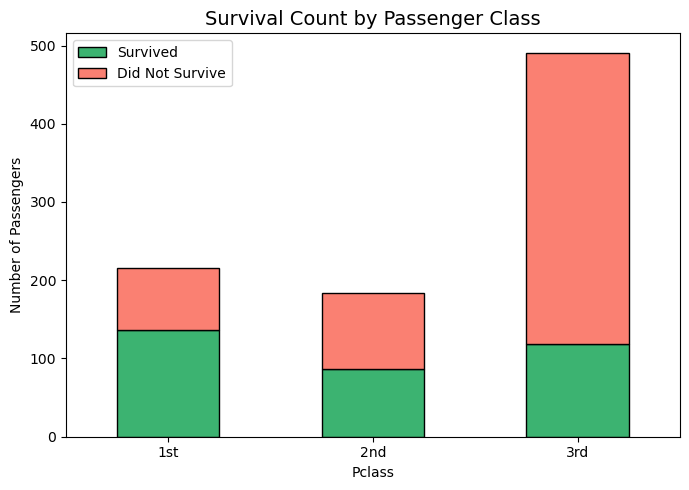

In [19]:
surv_by_class = df.groupby('Pclass')['Survived'].agg(['mean', 'sum', 'count'])
surv_by_class.columns = ['Survival Rate', 'Survived Count', 'Total']
surv_by_class['Did Not Survive'] = surv_by_class['Total'] - surv_by_class['Survived Count']
print(surv_by_class)

fig, ax = plt.subplots(figsize=(7, 5))
surv_by_class[['Survived Count', 'Did Not Survive']].plot(
    kind='bar', stacked=True, ax=ax,
    color=['mediumseagreen', 'salmon'], edgecolor='black'
)
ax.set_title('Survival Count by Passenger Class', fontsize=14)
ax.set_ylabel('Number of Passengers')
ax.set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
ax.legend(['Survived', 'Did Not Survive'])
plt.tight_layout()
plt.show()

**Interpretation:** There is a clear class-based gradient. 1st-class passengers had the highest survival rate (~63%), followed by 2nd class (~47%), and 3rd class had the lowest (~24%). Wealthier passengers likely had cabins closer to the boat deck and received priority during evacuation.

### Q3: Is there a noticeable pattern between age groups and survival?

We split passengers into age groups (Child: 0–12, Teen: 13–18, Adult: 19–60, Senior: 60+) and compare survival rates.

               Survival Rate  Survived  Total
AgeGroup                                     
Child (0-12)        0.579710        40     69
Teen (13-18)        0.428571        30     70
Adult (19-60)       0.365753       267    730
Senior (60+)        0.227273         5     22


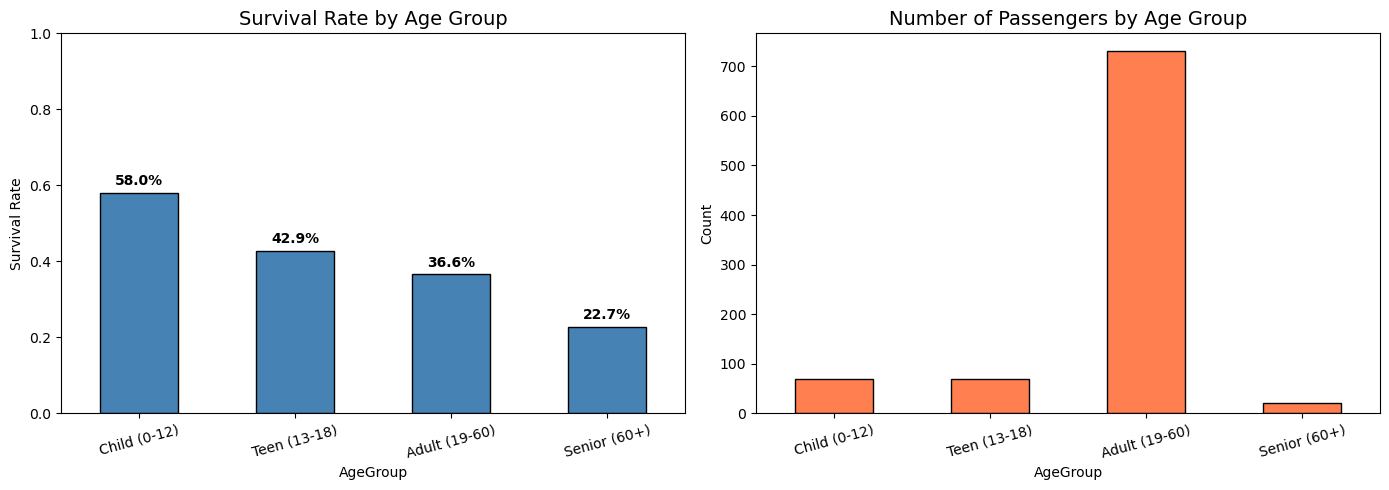

In [20]:
bins = [0, 12, 18, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Adult (19-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

surv_by_age = df.groupby('AgeGroup', observed=False)['Survived'].agg(['mean', 'sum', 'count'])
surv_by_age.columns = ['Survival Rate', 'Survived', 'Total']
print(surv_by_age)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surv_by_age['Survival Rate'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Survival Rate by Age Group', fontsize=14)
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(labels, rotation=15)
for i, v in enumerate(surv_by_age['Survival Rate']):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontweight='bold')

surv_by_age['Total'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Number of Passengers by Age Group', fontsize=14)
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(labels, rotation=15)

plt.tight_layout()
plt.show()

**Interpretation:** Children (age 0–12) had the highest survival rate, which again supports the "women and children first" evacuation policy. Teens and adults had lower rates, while seniors had the lowest — although the senior group is small, so the estimate is less reliable. The bulk of passengers were adults.

### Q4: Does paying a higher fare seem related to survival?

We compare fare distributions between survivors and non-survivors using both summary statistics and a boxplot.

                      mean   50%  min       max
Did Not Survive  22.117887  10.5  0.0  263.0000
Survived         48.395408  26.0  0.0  512.3292


/tmp/ipykernel_54596/672727158.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(


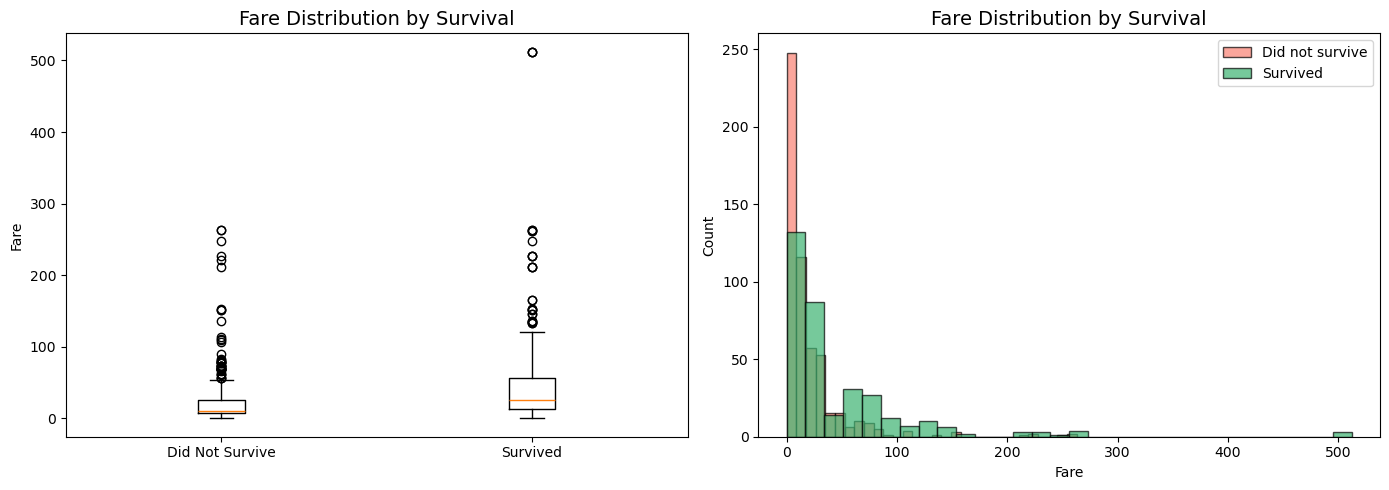

In [21]:
fare_stats = df.groupby('Survived')['Fare'].describe()
fare_stats.index = ['Did Not Survive', 'Survived']
print(fare_stats[['mean', '50%', 'min', 'max']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    [df[df['Survived'] == 0]['Fare'], df[df['Survived'] == 1]['Fare']],
    labels=['Did Not Survive', 'Survived']
)
axes[0].set_title('Fare Distribution by Survival', fontsize=14)
axes[0].set_ylabel('Fare')

survived_fare = df[df['Survived'] == 1]['Fare']
not_survived_fare = df[df['Survived'] == 0]['Fare']
axes[1].hist(not_survived_fare, bins=30, alpha=0.7, color='salmon', edgecolor='black', label='Did not survive')
axes[1].hist(survived_fare, bins=30, alpha=0.7, color='mediumseagreen', edgecolor='black', label='Survived')
axes[1].set_title('Fare Distribution by Survival', fontsize=14)
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:** Passengers who survived paid a noticeably higher fare on average. The median fare for survivors is also higher than for non-survivors. This makes sense because higher fares correspond to higher-class tickets, which we already showed are linked to better survival odds. So fare is essentially a proxy for class and cabin location.

### 4.2 Combined View: Gender × Class Survival

Finally, we cross-tabulate **Gender** and **Passenger Class** to see how these two factors interact.

Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


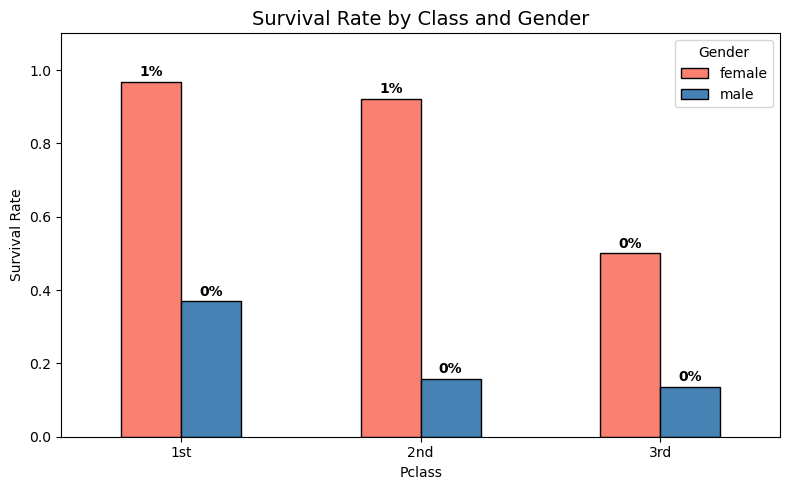

In [22]:
cross = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
print(cross)

fig, ax = plt.subplots(figsize=(8, 5))
cross.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='black')
ax.set_title('Survival Rate by Class and Gender', fontsize=14)
ax.set_ylabel('Survival Rate')
ax.set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
ax.set_ylim(0, 1.1)
ax.legend(title='Gender')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge',
                 padding=2, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** When we combine Gender and Class, the pattern is striking: women in 1st and 2nd class had near-perfect survival rates, while men in 3rd class had the worst odds. This cross-tabulation confirms that being female **and** in a higher class was the strongest combination for survival on the Titanic.

## Step 5 – Conclusion

### Key Findings

After loading, cleaning, exploring, and analyzing the Titanic dataset, the following patterns stand out:

- **Gender was the strongest survival factor.** Women survived at a rate of ~74%, compared to only ~19% for men. This is consistent with the historical "women and children first" evacuation protocol.

- **Passenger class mattered significantly.** 1st-class passengers had a ~63% survival rate, 2nd class ~47%, and 3rd class only ~24%. Higher class meant better access to lifeboats and closer proximity to the boat deck.

- **Children had the best survival odds among all age groups.** Passengers aged 0–12 survived at noticeably higher rates than teenagers, adults, or seniors, reinforcing the priority given to children during evacuation.

- **Higher fares were associated with higher survival.** Survivors paid a significantly higher average fare than non-survivors. Since fare is closely tied to passenger class, this effectively confirms the class–survival relationship from a different angle.

- **The combination of gender and class was especially powerful.** Women in 1st and 2nd class had near-perfect survival rates, while men in 3rd class had the worst outcomes.

### Limitations

- **Age imputation:** We filled 177 missing `Age` values with the median. A more sophisticated approach (e.g., imputing based on `Pclass` and `Sex` group medians) could yield more accurate results.
- **Cabin dropped entirely:** The `Cabin` column was too sparse to use, but it could have provided useful information about deck location and proximity to lifeboats.
- **Correlation ≠ causation:** This analysis identifies patterns and associations, not causal relationships. A proper predictive model (e.g., logistic regression or a decision tree) would be needed to quantify each factor's independent contribution.

### Reflection

The most striking takeaway is how strongly social factors — gender and economic class — determined who lived and who died. If time allowed, a natural next step would be to build a simple classification model to predict survival based on these features and evaluate its accuracy.